In [1]:
import pandas as pd
import numpy as np
import yaml

In [2]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

# Contamination dataframes

## AIR

### Air facilities > df1

In [3]:
df_air_releases_facilities = pd.read_csv(config['data']['raw']['file1'])
display(df_air_releases_facilities.head())
display(df_air_releases_facilities.dtypes)

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,Pollutant,Releases,confidentialityReason
0,2026/02/13,Germany,2013,1.0,Energy sector,1(e),https://registry.gdi-de.org/id/de.nw.inspire.p...,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,NaN,AIR,Sulphur oxides (SOX),824000.0,NaN
1,2026/02/13,Sweden,2020,7.0,Intensive livestock production and aquaculture,7(a)(i),SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,NaN,AIR,Ammonia (NH3),16300.0,NaN
2,2026/02/13,Romania,2013,5.0,Waste and wastewater management,5(d),RO.CAED/104TL0001.FACILITY,SC ECOREC SA,TULCEA,28.769671,45.190459,NaN,AIR,Methane (CH4),269000.0,NaN
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,NaN,AIR,Ammonia (NH3),31920.0,NaN
4,2026/02/13,Czechia,2007,1.0,Energy sector,1(c),CZ.MZP.U423/CZ14819275.FACILITY,energetika,Štětí,14.380370,50.462296,NaN,AIR,Sulphur oxides (SOX),507000.0,NaN


PublicationDate                  object
countryName                      object
reportingYear                     int64
EPRTR_SectorCode                float64
EPRTR_SectorName                 object
EPRTRAnnexIMainActivity          object
FacilityInspireId                object
facilityName                     object
city                             object
Longitude                       float64
Latitude                        float64
addressConfidentialityReason     object
TargetRelease                    object
Pollutant                        object
Releases                        float64
confidentialityReason            object
dtype: object

In [4]:
df_air_releases_facilities.PublicationDate.unique()

array(['2026/02/13'], dtype=object)

In [5]:
df_air_releases_facilities = df_air_releases_facilities.drop(columns=['PublicationDate', 'EPRTR_SectorCode', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'addressConfidentialityReason', 'confidentialityReason'])

In [6]:
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df1 = rename_columns(df_air_releases_facilities)


In [7]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    #print("\n    ---- df info ---")
    #print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df1)


    ----- Shape -----
(372206, 10)

    ---- Empty Values ---
countryname            0
reportingyear          0
eprtr_sectorname    4985
facilityname           1
city                 133
longitude            806
latitude             806
targetrelease          0
pollutant              0
releases              78
dtype: int64

    ----- Dtypes -----
countryname          object
reportingyear         int64
eprtr_sectorname     object
facilityname         object
city                 object
longitude           float64
latitude            float64
targetrelease        object
pollutant            object
releases            float64
dtype: object


In [8]:
df1.dropna(inplace=True)
print(df1.shape)

(366206, 10)


In [9]:
df1.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases
0,Germany,2013,Energy sector,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,AIR,Sulphur oxides (SOX),824000.0
1,Sweden,2020,Intensive livestock production and aquaculture,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,AIR,Ammonia (NH3),16300.0
2,Romania,2013,Waste and wastewater management,SC ECOREC SA,TULCEA,28.769671,45.190459,AIR,Methane (CH4),269000.0
3,Italy,2021,Intensive livestock production and aquaculture,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920.0
4,Czechia,2007,Energy sector,energetika,Štětí,14.380370,50.462296,AIR,Sulphur oxides (SOX),507000.0


In [10]:
df1.isnull().sum()

countryname         0
reportingyear       0
eprtr_sectorname    0
facilityname        0
city                0
longitude           0
latitude            0
targetrelease       0
pollutant           0
releases            0
dtype: int64

### Air releases national > df2

In [11]:
df_air_releases_national = pd.read_csv(config['data']['raw']['file3'])
display(df_air_releases_national.head())
display(df_air_releases_national.dtypes)
display(df_air_releases_national.shape)

,PublicationDate,countryName,reportingYear,Pollutant,Releases
0,2026/02/13,France,2023,Tetrachloroethylene,1.108000e+04
1,2026/02/13,Poland,2012,Methane (CH4),4.971020e+08
2,2026/02/13,Czechia,2013,Methane (CH4),1.865000e+06
3,2026/02/13,Portugal,2024,Pentachlorobenzene,1.070000e+00
4,2026/02/13,Bulgaria,2009,Non-methane volatile organic compounds (NMVOC),3.964000e+06


PublicationDate     object
countryName         object
reportingYear        int64
Pollutant           object
Releases           float64
dtype: object

(13639, 5)

In [12]:
df_air_releases_national = df_air_releases_national.drop(columns=['PublicationDate'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df2 = rename_columns(df_air_releases_national)

df2.dropna(inplace=True)
print(df2.shape)

(13639, 4)


In [13]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df2)


    ----- Shape -----
(13639, 4)

    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13639 entries, 0 to 13638
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryname    13639 non-null  object 
 1   reportingyear  13639 non-null  int64  
 2   pollutant      13639 non-null  object 
 3   releases       13639 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 426.3+ KB
None

    ---- Empty Values ---
countryname      0
reportingyear    0
pollutant        0
releases         0
dtype: int64

    ----- Dtypes -----
countryname       object
reportingyear      int64
pollutant         object
releases         float64
dtype: object


### Air releases sector > df3

In [14]:
df_air_releases_sector = pd.read_csv(config['data']['raw']['file4'])
display(df_air_releases_sector.head())
display(df_air_releases_sector.dtypes)
display(df_air_releases_sector.shape)

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,Pollutant,Releases
0,2026/02/13,Norway,2013,3.0,Mineral industry,Mercury and compounds (as Hg),2.500000e+01
1,2026/02/13,Czechia,2014,1.0,Energy sector,Arsenic and compounds (as As),1.363400e+03
2,2026/02/13,Italy,2008,1.0,Energy sector,Nitrogen oxides (NOX),1.039530e+08
3,2026/02/13,Spain,2018,1.0,Energy sector,Carbon dioxide (CO2),7.229500e+10
4,2026/02/13,Serbia,2022,1.0,Energy sector,Sulphur oxides (SOX),3.087640e+08


PublicationDate      object
countryName          object
reportingYear         int64
EPRTR_SectorCode    float64
EPRTR_SectorName     object
Pollutant            object
Releases            float64
dtype: object

(42000, 7)

In [15]:
df_air_releases_sector = df_air_releases_sector.drop(columns=['PublicationDate'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df3 = rename_columns(df_air_releases_national)

df3.dropna(inplace=True)
print(df3.shape)

(13639, 4)


In [16]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df3)


    ----- Shape -----
(13639, 4)

    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13639 entries, 0 to 13638
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryname    13639 non-null  object 
 1   reportingyear  13639 non-null  int64  
 2   pollutant      13639 non-null  object 
 3   releases       13639 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 426.3+ KB
None

    ---- Empty Values ---
countryname      0
reportingyear    0
pollutant        0
releases         0
dtype: int64

    ----- Dtypes -----
countryname       object
reportingyear      int64
pollutant         object
releases         float64
dtype: object


## WATER

### Water facilities > df4

In [17]:
df_water_releases_facilities = pd.read_csv(config['data']['raw']['file2'])
display(df_water_releases_facilities.head())
display(df_water_releases_facilities.dtypes)

C:\Users\fotos\AppData\Local\Temp\ipykernel_15000\3054174240.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_water_releases_facilities = pd.read_csv(config['data']['raw']['file2'])


,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,Pollutant,Releases,confidentialityReason
0,2026/02/13,United Kingdom,2014,1.0,Energy sector,1(c),UK.CAED/BEISOffsh-Forties-Alpha.FACILITY,Forties Alpha,--,0.582170,57.435510,NaN,WATER,Anthracene,12.10,NaN
1,2026/02/13,Germany,2011,4.0,Chemical industry,4(b)(iv),https://registry.gdi-de.org/id/de.nw.inspire.p...,Solvay GmbH,Rheinberg,6.577830,51.564710,NaN,WATER,Cadmium and compounds (as Cd),113.00,NaN
2,2026/02/13,Germany,2022,5.0,Waste and wastewater management,5(f),https://registry.gdi-de.org/id/de.by.inspire.p...,AmperVerband,Olching,11.360499,48.233805,NaN,WATER,Total organic carbon(as total C or COD/3) (TOC),77700.00,NaN
3,2026/02/13,Hungary,2007,5.0,Waste and wastewater management,5(f),HU.OKIR/100609995.FACILITY,Fővárosi Csatornázási Művek Zrt.,Budapest 04. ker.,19.073994,47.572780,NaN,WATER,Mercury and compounds (as Hg),5.05,NaN
4,2026/02/13,Portugal,2014,1.0,Energy sector,1(a),PT.CAED/PT.APA05769662.CI,Refinaria de Sines (CI),SINES,-8.800138,37.963901,NaN,WATER,Total organic carbon(as total C or COD/3) (TOC),62100.00,NaN


PublicationDate                  object
countryName                      object
reportingYear                     int64
EPRTR_SectorCode                float64
EPRTR_SectorName                 object
EPRTRAnnexIMainActivity          object
FacilityInspireId                object
facilityName                     object
city                             object
Longitude                       float64
Latitude                        float64
addressConfidentialityReason     object
TargetRelease                    object
Pollutant                        object
Releases                        float64
confidentialityReason            object
dtype: object

In [18]:
df_water_releases_facilities = df_water_releases_facilities.drop(columns=['PublicationDate', 'EPRTR_SectorCode', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'addressConfidentialityReason', 'confidentialityReason'])

In [19]:
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df4 = rename_columns(df_water_releases_facilities)

df4.dropna(inplace=True)
print(df4.shape)

(251384, 10)


In [20]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df4)


    ----- Shape -----
(251384, 10)

    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
Index: 251384 entries, 0 to 254155
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   countryname       251384 non-null  object 
 1   reportingyear     251384 non-null  int64  
 2   eprtr_sectorname  251384 non-null  object 
 3   facilityname      251384 non-null  object 
 4   city              251384 non-null  object 
 5   longitude         251384 non-null  float64
 6   latitude          251384 non-null  float64
 7   targetrelease     251384 non-null  object 
 8   pollutant         251384 non-null  object 
 9   releases          251384 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 21.1+ MB
None

    ---- Empty Values ---
countryname         0
reportingyear       0
eprtr_sectorname    0
facilityname        0
city                0
longitude           0
latitude            0
targetrelea

In [21]:
df4.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases
0,United Kingdom,2014,Energy sector,Forties Alpha,--,0.582170,57.435510,WATER,Anthracene,12.10
1,Germany,2011,Chemical industry,Solvay GmbH,Rheinberg,6.577830,51.564710,WATER,Cadmium and compounds (as Cd),113.00
2,Germany,2022,Waste and wastewater management,AmperVerband,Olching,11.360499,48.233805,WATER,Total organic carbon(as total C or COD/3) (TOC),77700.00
3,Hungary,2007,Waste and wastewater management,Fővárosi Csatornázási Művek Zrt.,Budapest 04. ker.,19.073994,47.572780,WATER,Mercury and compounds (as Hg),5.05
4,Portugal,2014,Energy sector,Refinaria de Sines (CI),SINES,-8.800138,37.963901,WATER,Total organic carbon(as total C or COD/3) (TOC),62100.00


In [22]:
df4.isnull().sum()

countryname         0
reportingyear       0
eprtr_sectorname    0
facilityname        0
city                0
longitude           0
latitude            0
targetrelease       0
pollutant           0
releases            0
dtype: int64

### Water releases national > df5

In [23]:
df_water_releases_national = pd.read_csv(config['data']['raw']['file5'])
display(df_water_releases_national.head())
display(df_water_releases_national.dtypes)
display(df_water_releases_national.shape)

,PublicationDate,countryName,reportingYear,Pollutant,Releases
0,2026/02/13,Italy,2019,Total nitrogen,24776324.60
1,2026/02/13,Belgium,2018,Fluoranthene,3.08
2,2026/02/13,Finland,2013,Phenols (as total C),544.20
3,2026/02/13,Germany,2020,Isoproturon,30.80
4,2026/02/13,Germany,2010,Total phosphorus,1856310.00


PublicationDate     object
countryName         object
reportingYear        int64
Pollutant           object
Releases           float64
dtype: object

(12607, 5)

In [24]:
df_water_releases_national = df_water_releases_national.drop(columns=['PublicationDate'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df5 = rename_columns(df_water_releases_national)

df5.dropna(inplace=True)
print(df5.shape)

(12607, 4)


In [25]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df5)


    ----- Shape -----
(12607, 4)

    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12607 entries, 0 to 12606
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryname    12607 non-null  object 
 1   reportingyear  12607 non-null  int64  
 2   pollutant      12607 non-null  object 
 3   releases       12607 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 394.1+ KB
None

    ---- Empty Values ---
countryname      0
reportingyear    0
pollutant        0
releases         0
dtype: int64

    ----- Dtypes -----
countryname       object
reportingyear      int64
pollutant         object
releases         float64
dtype: object


### Water releases sector > df6

In [26]:
df_water_releases_sector = pd.read_csv(config['data']['raw']['file6'])
display(df_water_releases_sector.head())
display(df_water_releases_sector.dtypes)
display(df_water_releases_sector.shape)

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,Pollutant,Releases
0,2026/02/13,Germany,2024,2.0,Production and processing of metals,Zinc and compounds (as Zn),11370.0
1,2026/02/13,Germany,2013,5.0,Waste and wastewater management,Total nitrogen,38222100.0
2,2026/02/13,Netherlands,2024,5.0,Waste and wastewater management,Cyanides (as total CN),655.0
3,2026/02/13,Sweden,2016,6.0,Paper and wood production and processing,Total nitrogen,1728800.0
4,2026/02/13,Italy,2007,6.0,Paper and wood production and processing,Chromium and compounds (as Cr),452.2


PublicationDate      object
countryName          object
reportingYear         int64
EPRTR_SectorCode    float64
EPRTR_SectorName     object
Pollutant            object
Releases            float64
dtype: object

(33132, 7)

In [27]:
df_water_releases_sector = df_water_releases_sector.drop(columns=['PublicationDate'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df6 = rename_columns(df_water_releases_sector)

df6.dropna(inplace=True)
print(df6.shape)

(32227, 6)


In [28]:
def df_info(df):
    print("\n    ----- Shape -----")
    print(df.shape)
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    #print("\n    ---- Statistics ---")
    #return df.describe()
df_info(df6)


    ----- Shape -----
(32227, 6)

    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
Index: 32227 entries, 0 to 33131
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   countryname       32227 non-null  object 
 1   reportingyear     32227 non-null  int64  
 2   eprtr_sectorcode  32227 non-null  float64
 3   eprtr_sectorname  32227 non-null  object 
 4   pollutant         32227 non-null  object 
 5   releases          32227 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.7+ MB
None

    ---- Empty Values ---
countryname         0
reportingyear       0
eprtr_sectorcode    0
eprtr_sectorname    0
pollutant           0
releases            0
dtype: int64

    ----- Dtypes -----
countryname          object
reportingyear         int64
eprtr_sectorcode    float64
eprtr_sectorname     object
pollutant            object
releases            float64
dtype: object


# NUTS - facilities df

In [29]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

## NUTS Water -> df1_NUTS

In [30]:
df1_NUTS = df1.dropna(subset=['longitude', 'latitude']).copy()

In [31]:
geometry = [Point(xy) for xy in zip(df1_NUTS['longitude'], df1_NUTS['latitude'])]
gdf_puntos = gpd.GeoDataFrame(df1_NUTS, geometry=geometry, crs="EPSG:4326")

In [32]:
url_nuts = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_10M_2024_4326.geojson"
gdf_nuts = gpd.read_file(url_nuts)

In [33]:
gdf_nuts_2 = gdf_nuts[gdf_nuts['LEVL_CODE'] == 2]

In [34]:
df1_NUTS = gpd.sjoin(gdf_puntos, gdf_nuts_2, how="left", predicate="within")

In [35]:
df1_NUTS = pd.DataFrame(df1_NUTS).drop(columns=['geometry', 'index_right'])

In [36]:
df1_NUTS.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases,...,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM
0,Germany,2013,Energy sector,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,AIR,Sulphur oxides (SOX),824000.0,...,NaN,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland
1,Sweden,2020,Intensive livestock production and aquaculture,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,AIR,Ammonia (NH3),16300.0,...,NaN,Sweden,Suède,SWE,UN Member State,Stockholm,T,F,F,Schweden
2,Romania,2013,Waste and wastewater management,SC ECOREC SA,TULCEA,28.769671,45.190459,AIR,Methane (CH4),269000.0,...,NaN,Romania,Roumanie,ROU,UN Member State,Bucharest,T,F,F,Rumänien
3,Italy,2021,Intensive livestock production and aquaculture,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920.0,...,NaN,Italy,Italie,ITA,UN Member State,Rome,T,F,F,Italien
4,Czechia,2007,Energy sector,energetika,Štětí,14.380370,50.462296,AIR,Sulphur oxides (SOX),507000.0,...,NaN,Czechia,Tchéquie,CZE,UN Member State,Prague,T,F,F,Tschechien


In [37]:
df1_NUTS.dtypes

countryname          object
reportingyear         int64
eprtr_sectorname     object
facilityname         object
city                 object
longitude           float64
latitude            float64
targetrelease        object
pollutant            object
releases            float64
NUTS_ID              object
LEVL_CODE           float64
CNTR_CODE            object
NAME_LATN            object
NUTS_NAME            object
MOUNT_TYPE          float64
URBN_TYPE           float64
COAST_TYPE          float64
NAME_ENGL            object
NAME_FREN            object
ISO3_CODE            object
SVRG_UN              object
CAPT                 object
EU_STAT              object
EFTA_STAT            object
CC_STAT              object
NAME_GERM            object
dtype: object

In [38]:
df1_NUTS_clean = df1_NUTS.drop(columns=['NAME_LATN', 'NAME_ENGL', 'NAME_FREN', 'SVRG_UN', 'CAPT', 'EU_STAT', 'EU_STAT', 'CC_STAT', 'NAME_GERM', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'EFTA_STAT', 'LEVL_CODE'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df1_NUTS_clean = rename_columns(df1_NUTS_clean)

In [39]:
df1_NUTS_clean['releases'] = df1_NUTS_clean['releases'].astype(int)
df1_NUTS_clean.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases,nuts_id,cntr_code,nuts_name,iso3_code
0,Germany,2013,Energy sector,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,AIR,Sulphur oxides (SOX),824000,DEA2,DE,Köln,DEU
1,Sweden,2020,Intensive livestock production and aquaculture,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,AIR,Ammonia (NH3),16300,SE22,SE,Sydsverige,SWE
2,Romania,2013,Waste and wastewater management,SC ECOREC SA,TULCEA,28.769671,45.190459,AIR,Methane (CH4),269000,RO22,RO,Sud-Est,ROU
3,Italy,2021,Intensive livestock production and aquaculture,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920,ITH3,IT,Veneto,ITA
4,Czechia,2007,Energy sector,energetika,Štětí,14.380370,50.462296,AIR,Sulphur oxides (SOX),507000,CZ04,CZ,Severozápad,CZE


## NUTS Air -> df4_NUTS

In [40]:
df4_NUTS = df4.dropna(subset=['longitude', 'latitude']) . copy()

geometry = [Point(xy) for xy in zip(df4_NUTS['longitude' ], df4_NUTS['latitude' ])]
gdf_puntos = gpd.GeoDataFrame(df4_NUTS, geometry=geometry, crs="EPSG:4326")

url_nuts = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_10M_2024_4326.geojson"
gdf_nuts = gpd.read_file(url_nuts)

gdf_nuts_2 = gdf_nuts[gdf_nuts['LEVL_CODE' ] == 2]

df4_NUTS = gpd.sjoin(gdf_puntos, gdf_nuts_2, how="left", predicate="within")

df4_NUTS = pd.DataFrame(df4_NUTS).drop(columns=['geometry', 'index_right'])

In [41]:
df4_NUTS_clean = df4_NUTS.drop(columns=['NAME_LATN', 'NAME_ENGL', 'NAME_FREN', 'SVRG_UN', 'CAPT', 'EU_STAT', 'EU_STAT', 'CC_STAT', 'NAME_GERM', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'EFTA_STAT', 'LEVL_CODE'])
def rename_columns(df):
    df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
    df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)
    return df

df4_NUTS_clean = rename_columns(df4_NUTS_clean)

In [42]:
df4_NUTS_clean['releases'] = df4_NUTS_clean['releases'].astype(int)
df4_NUTS_clean.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases,nuts_id,cntr_code,nuts_name,iso3_code
0,United Kingdom,2014,Energy sector,Forties Alpha,--,0.582170,57.435510,WATER,Anthracene,12,NaN,NaN,NaN,NaN
1,Germany,2011,Chemical industry,Solvay GmbH,Rheinberg,6.577830,51.564710,WATER,Cadmium and compounds (as Cd),113,DEA1,DE,Düsseldorf,DEU
2,Germany,2022,Waste and wastewater management,AmperVerband,Olching,11.360499,48.233805,WATER,Total organic carbon(as total C or COD/3) (TOC),77700,DE21,DE,Oberbayern,DEU
3,Hungary,2007,Waste and wastewater management,Fővárosi Csatornázási Művek Zrt.,Budapest 04. ker.,19.073994,47.572780,WATER,Mercury and compounds (as Hg),5,HU11,HU,Budapest,HUN
4,Portugal,2014,Energy sector,Refinaria de Sines (CI),SINES,-8.800138,37.963901,WATER,Total organic carbon(as total C or COD/3) (TOC),62100,PT1C,PT,Alentejo,PRT


In [43]:
df1_NUTS_clean.nuts_id.isna().value_counts()

nuts_id
False    321861
True      44345
Name: count, dtype: int64

In [44]:
df4_NUTS_clean.dtypes

countryname          object
reportingyear         int64
eprtr_sectorname     object
facilityname         object
city                 object
longitude           float64
latitude            float64
targetrelease        object
pollutant            object
releases              int64
nuts_id              object
cntr_code            object
nuts_name            object
iso3_code            object
dtype: object

In [45]:
df1_NUTS_clean.dtypes

countryname          object
reportingyear         int64
eprtr_sectorname     object
facilityname         object
city                 object
longitude           float64
latitude            float64
targetrelease        object
pollutant            object
releases              int64
nuts_id              object
cntr_code            object
nuts_name            object
iso3_code            object
dtype: object

 ## To .csv

In [46]:
#df1_NUTS_clean.to_csv('air_nuts_clean.csv', index=False, encoding='utf-8')

In [47]:
#df4_NUTS_clean.to_csv('water_nuts_clean.csv', index=False, encoding='utf-8')

# Pollutants

## To the air

In [48]:
df1.pollutant.unique()

array(['Sulphur oxides (SOX)', 'Ammonia (NH3)', 'Methane (CH4)',
       'Particulate matter (PM10)', 'Chlorofluorocarbons (CFCs)',
       'Carbon dioxide (CO2)', 'Nitrous oxide (N2O)',
       'Fluorine and inorganic compounds (as HF)',
       'Chlorine and inorganic compounds (as HCl)', 'Naphthalene',
       'Cadmium and compounds (as Cd)', 'Nitrogen oxides (NOX)',
       'Hydro-fluorocarbons (HFCS)', 'Nickel and compounds (as Ni)',
       'Hydrochlorofluorocarbons (HCFCs)',
       'Non-methane volatile organic compounds (NMVOC)',
       'Zinc and compounds (as Zn)', 'Hydrogen cyanide (HCN)',
       'Carbon dioxide (CO2) excluding biomass',
       'Mercury and compounds (as Hg)', 'Benzene',
       'Polycyclic aromatic hydrocarbons (PAHs)', 'Carbon monoxide (CO)',
       'Chromium and compounds (as Cr)', 'Perfluorocarbons (PFCs)',
       'Arsenic and compounds (as As)', 'Anthracene',
       'PCDD + PCDF (dioxins + furans) (as Teq)',
       'Polychlorinated biphenyls (PCBs)',
       '1,1

In [49]:
# filtering df - df1_NUTS_clean

respiratory_chemicals = [
    'Fine particulate matter (PM2.5)', 
    'Particulate matter (PM10)', 
    'Nitrogen oxides (NOX)', 
    'Sulphur oxides (SOX)',
    'Asbestos', 
    'Cadmium and compounds (as Cd)', 
    'Chromium and compounds (as Cr)', 
    'Nickel and compounds (as Ni)', 
    'Arsenic and compounds (as As)', 
    'Polycyclic aromatic hydrocarbons (PAHs)', 
    'Benzo(g,h,i)perylene', 
    'Fluoranthene', 
    'Anthracene',
    'Ammonia (NH3)', 
    'Chlorine and inorganic compounds (as HCl)', 
    'Fluorine and inorganic compounds (as HF)', 
    'Ethylene oxide',
    'Non-methane volatile organic compounds (NMVOC)', 
    'Benzene', 
    'Toluene', 
    'Xylenes', 
    'Ethyl benzene', 
    'Vinyl chloride'
]


df_respiratory_emissions = df1_NUTS_clean[df1_NUTS_clean['pollutant'].isin(respiratory_chemicals)]

print(f"rows after filtering: {len(df_respiratory_emissions)}")
print("pollutants present in the df")
print(df_respiratory_emissions['pollutant'].unique())

df_respiratory_emissions.to_csv('df_respiratory_emissions_clean.csv', index=False, sep=';', decimal=',')

rows after filtering: 229184
pollutants present in the df
['Sulphur oxides (SOX)' 'Ammonia (NH3)' 'Particulate matter (PM10)'
 'Fluorine and inorganic compounds (as HF)'
 'Chlorine and inorganic compounds (as HCl)'
 'Cadmium and compounds (as Cd)' 'Nitrogen oxides (NOX)'
 'Nickel and compounds (as Ni)'
 'Non-methane volatile organic compounds (NMVOC)' 'Benzene'
 'Polycyclic aromatic hydrocarbons (PAHs)'
 'Chromium and compounds (as Cr)' 'Arsenic and compounds (as As)'
 'Anthracene' 'Benzo(g,h,i)perylene' 'Fine particulate matter (PM2.5)'
 'Vinyl chloride' 'Fluoranthene' 'Ethyl benzene' 'Ethylene oxide'
 'Toluene' 'Asbestos' 'Xylenes']


In [50]:
df_respiratory_emissions.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases,nuts_id,cntr_code,nuts_name,iso3_code
0,Germany,2013,Energy sector,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,AIR,Sulphur oxides (SOX),824000,DEA2,DE,Köln,DEU
1,Sweden,2020,Intensive livestock production and aquaculture,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,AIR,Ammonia (NH3),16300,SE22,SE,Sydsverige,SWE
3,Italy,2021,Intensive livestock production and aquaculture,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920,ITH3,IT,Veneto,ITA
4,Czechia,2007,Energy sector,energetika,Štětí,14.380370,50.462296,AIR,Sulphur oxides (SOX),507000,CZ04,CZ,Severozápad,CZE
5,Spain,2016,Energy sector,"PETROLEOS DEL NORTE, PETRONOR, S.A. (PETRONOR)",Muskiz,-3.110944,43.325743,AIR,Sulphur oxides (SOX),7340000,ES21,ES,País Vasco,ESP


## To the water

In [51]:
df4.pollutant.unique()

array(['Anthracene', 'Cadmium and compounds (as Cd)',
       'Total organic carbon(as total C or COD/3) (TOC)',
       'Mercury and compounds (as Hg)', 'Zinc and compounds (as Zn)',
       'Chlorides (as total Cl)', 'Total nitrogen',
       '1,2-dichloroethane (DCE-1,2)', 'Chromium and compounds (as Cr)',
       'Ammonia (NH3)', 'Total phosphorus',
       'Copper and compounds (as Cu)', 'Arsenic and compounds (as As)',
       'Nickel and compounds (as Ni)', 'Lead and compounds (as Pb)',
       'Tetrachloromethane (TCM)', 'Benzene', 'Lindane',
       'Halogenated organic compounds (as AOX)', 'Phenols (as total C)',
       'Fluorides (as total F)',
       'Nonylphenol and Nonylphenol ethoxylates',
       'Di-(2-ethyl hexyl) phthalate (DEHP)', 'Trichloromethane',
       'Toluene', 'Ethyl benzene', 'Trichlorobenzenes (TCB)',
       'Naphthalene', 'Polycyclic aromatic hydrocarbons (PAHs)',
       'Octylphenols and Octylphenol ethoxylates',
       'Polychlorinated biphenyls (PCBs)', 'Cyanide

In [52]:
# filtering df - df4_NUTS_clean

water_disease_chemicals = [
   
    'Arsenic and compounds (as As)', 'Cadmium and compounds (as Cd)', 
    'Mercury and compounds (as Hg)', 'Lead and compounds (as Pb)',
    'Chromium and compounds (as Cr)', 'Nickel and compounds (as Ni)',
    
    'PCDD + PCDF (dioxins + furans) (as Teq)', 'Polychlorinated biphenyls (PCBs)',
    'Polycyclic aromatic hydrocarbons (PAHs)', 'Hexachlorobenzene (HCB)', 
    'Pentachlorophenol (PCP)', 'Brominated diphenylethers (PBDE)',
    
    'DDT (DDT)', 'Lindane', 'Aldrin', 'Dieldrin', 'Endrin', 'Chlordane', 
    'Heptachlor', 'Toxaphene', 'Mirex', 'Chlorpyrifos', 'Atrazine', 
    'Alachlor', 'Simazine', 'Diuron', 'Chlordecone', 'Isodrin',
    
    'Benzene', 'Vinyl chloride', 'Di-(2-ethyl hexyl) phthalate (DEHP)', 
    'Nonylphenol and Nonylphenol ethoxylates', 'Cyanides (as total CN)', 
    'Hydrogen cyanide (HCN)', 'Trichloroethylene (TRI)', 'Tetrachloroethylene',
    'Dichloromethane (DCM)', 'Asbestos', 'Halogenated organic compounds (as AOX)'
]

#
df_water_filtered = df4_NUTS_clean[df4_NUTS_clean['pollutant'].isin(water_disease_chemicals)]

print(f"rows after filtering: {len(df_water_filtered)}")
print("pollutants present in the df")
print(df_water_filtered['pollutant'].unique())

df_water_filtered.to_csv('df_water_disease_chemicals.csv', index=False, sep=';', decimal=',')

rows after filtering: 89021
pollutants present in the df
['Cadmium and compounds (as Cd)' 'Mercury and compounds (as Hg)'
 'Chromium and compounds (as Cr)' 'Arsenic and compounds (as As)'
 'Nickel and compounds (as Ni)' 'Lead and compounds (as Pb)' 'Benzene'
 'Lindane' 'Halogenated organic compounds (as AOX)'
 'Nonylphenol and Nonylphenol ethoxylates'
 'Di-(2-ethyl hexyl) phthalate (DEHP)'
 'Polycyclic aromatic hydrocarbons (PAHs)'
 'Polychlorinated biphenyls (PCBs)' 'Cyanides (as total CN)' 'Diuron'
 'Dichloromethane (DCM)' 'Pentachlorophenol (PCP)' 'Chlordecone'
 'Asbestos' 'Brominated diphenylethers (PBDE)' 'Dieldrin' 'Atrazine'
 'Heptachlor' 'PCDD + PCDF (dioxins + furans) (as Teq)'
 'Trichloroethylene (TRI)' 'Tetrachloroethylene' 'Aldrin' 'Chlorpyrifos'
 'Isodrin' 'Endrin' 'Hexachlorobenzene (HCB)' 'Vinyl chloride' 'Simazine'
 'Toxaphene' 'DDT (DDT)' 'Chlordane' 'Alachlor' 'Hydrogen cyanide (HCN)'
 'Mirex']


In [53]:
df_respiratory_emissions.head()

,countryname,reportingyear,eprtr_sectorname,facilityname,city,longitude,latitude,targetrelease,pollutant,releases,nuts_id,cntr_code,nuts_name,iso3_code
0,Germany,2013,Energy sector,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,AIR,Sulphur oxides (SOX),824000,DEA2,DE,Köln,DEU
1,Sweden,2020,Intensive livestock production and aquaculture,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,AIR,Ammonia (NH3),16300,SE22,SE,Sydsverige,SWE
3,Italy,2021,Intensive livestock production and aquaculture,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920,ITH3,IT,Veneto,ITA
4,Czechia,2007,Energy sector,energetika,Štětí,14.380370,50.462296,AIR,Sulphur oxides (SOX),507000,CZ04,CZ,Severozápad,CZE
5,Spain,2016,Energy sector,"PETROLEOS DEL NORTE, PETRONOR, S.A. (PETRONOR)",Muskiz,-3.110944,43.325743,AIR,Sulphur oxides (SOX),7340000,ES21,ES,País Vasco,ESP


# Adding cleaned datasets

## Health

In [54]:
df_life_exp_nuts2_long_clean = pd.read_csv(config['data']['cleam']['file11'], sep=';')
df_mortality_nuts2_long = pd.read_csv(config['data']['cleam']['file12'], sep=';')

## pollutants

In [55]:
air_nuts_clean = pd.read_csv(config['data']['cleam']['file10'])
water_nuts_clean = pd.read_csv(config['data']['cleam']['file13'])

# Graphs

This section builds on the cleaned, NUTS-joined exports from earlier in this notebook (`air_nuts_clean.csv`, `water_nuts_clean.csv`). It's self-contained — you can restart the kernel and run just this section, as long as those two files sit alongside the notebook.

**A quick methodology note.** Air releases are dominated by CO2 by several orders of magnitude, and water releases are dominated by bulk indicators like chlorides. Summing raw kilograms across both media would just reproduce the air ranking, so most charts below either keep air and water as separate panels, or compare each sector/country as a **share of its own medium's total** — that keeps the comparison honest without mixing incompatible scales. Release figures are assumed to be reported in kilograms per year, per the standard E-PRTR convention; worth a quick check against your `config.yaml` / data dictionary if you have it.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from matplotlib.colors import LogNorm

In [57]:
AIR = "#E0623F"         
WATER = "#1E8C8A"        
INK = "#26272B"          
SUBTLE = "#8A8D93"        
PAPER = "#FBFAF8"         
GOLD = "#D4A24C"         
GRID = "#E4E1DA"

AIR_CMAP = LinearSegmentedColormap.from_list("air_cmap", ["#F6D3C4", AIR])
WATER_CMAP = LinearSegmentedColormap.from_list("water_cmap", ["#BFE3E1", WATER])

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "text.color": INK,
    "axes.edgecolor": SUBTLE,
    "axes.labelcolor": INK,
    "axes.facecolor": PAPER,
    "figure.facecolor": PAPER,
    "savefig.facecolor": PAPER,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.grid": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
})


def fmt_mass(kg):
    """Format a kg quantity into a readable tonnes-based label."""
    tonnes = kg / 1000.0
    absval = abs(tonnes)
    if absval >= 1e9:
        return f"{tonnes/1e9:,.1f} Gt"
    if absval >= 1e6:
        return f"{tonnes/1e6:,.1f} Mt"
    if absval >= 1e3:
        return f"{tonnes/1e3:,.1f} kt"
    return f"{tonnes:,.0f} t"


def clean_spines(ax, left=True, bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if not left:
        ax.spines["left"].set_visible(False)
    if not bottom:
        ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color(SUBTLE)
    ax.spines["bottom"].set_color(SUBTLE)


def add_source_note(fig, note, y=-0.02):
    fig.text(0.01, y, note, fontsize=8, color=SUBTLE, ha="left", va="top", style="italic")


def wrap(s, width=30):
    words = s.split()
    lines, cur = [], ""
    for w in words:
        if len(cur) + len(w) + 1 <= width:
            cur = (cur + " " + w).strip()
        else:
            lines.append(cur)
            cur = w
    lines.append(cur)
    return "\n".join(lines)


# ---------------------------------------------------------------------------
# Load the cleaned, NUTS-joined datasets exported earlier in this notebook
# ---------------------------------------------------------------------------
air = air_nuts_clean
water = water_nuts_clean

print(f"Air releases:   {len(air):,} records | {air['reportingyear'].min()}-{air['reportingyear'].max()}")
print(f"Water releases: {len(water):,} records | {water['reportingyear'].min()}-{water['reportingyear'].max()}")


respiratory_chemicals = [
    'Fine particulate matter (PM2.5)', 'Particulate matter (PM10)', 'Nitrogen oxides (NOX)', 'Sulphur oxides (SOX)',
    'Asbestos', 'Cadmium and compounds (as Cd)', 'Chromium and compounds (as Cr)', 'Nickel and compounds (as Ni)',
    'Arsenic and compounds (as As)', 'Polycyclic aromatic hydrocarbons (PAHs)', 'Benzo(g,h,i)perylene', 'Fluoranthene', 'Anthracene',
    'Ammonia (NH3)', 'Chlorine and inorganic compounds (as HCl)', 'Fluorine and inorganic compounds (as HF)', 'Ethylene oxide',
    'Non-methane volatile organic compounds (NMVOC)', 'Benzene', 'Toluene', 'Xylenes', 'Ethyl benzene', 'Vinyl chloride'
]
water_disease_chemicals = [
    'Arsenic and compounds (as As)', 'Cadmium and compounds (as Cd)', 'Mercury and compounds (as Hg)', 'Lead and compounds (as Pb)',
    'Chromium and compounds (as Cr)', 'Nickel and compounds (as Ni)', 'PCDD + PCDF (dioxins + furans) (as Teq)', 'Polychlorinated biphenyls (PCBs)',
    'Polycyclic aromatic hydrocarbons (PAHs)', 'Hexachlorobenzene (HCB)', 'Pentachlorophenol (PCP)', 'Brominated diphenylethers (PBDE)',
    'DDT (DDT)', 'Lindane', 'Aldrin', 'Dieldrin', 'Endrin', 'Chlordane', 'Heptachlor', 'Toxaphene', 'Mirex', 'Chlorpyrifos', 'Atrazine',
    'Alachlor', 'Simazine', 'Diuron', 'Chlordecone', 'Isodrin', 'Benzene', 'Vinyl chloride', 'Di-(2-ethyl hexyl) phthalate (DEHP)',
    'Nonylphenol and Nonylphenol ethoxylates', 'Cyanides (as total CN)', 'Hydrogen cyanide (HCN)', 'Trichloroethylene (TRI)', 'Tetrachloroethylene',
    'Dichloromethane (DCM)', 'Asbestos', 'Halogenated organic compounds (as AOX)'
]

Air releases:   366,206 records | 2007-2024
Water releases: 251,384 records | 2007-2024


## 1. Which industry sectors pollute the most?

The **energy sector accounts for 67% of all reported air release mass** (almost entirely CO2 from power generation), while the **chemical industry accounts for 50% of all reported water release mass**. These are essentially two different pollution stories — the sector that dominates one medium barely registers in the other.

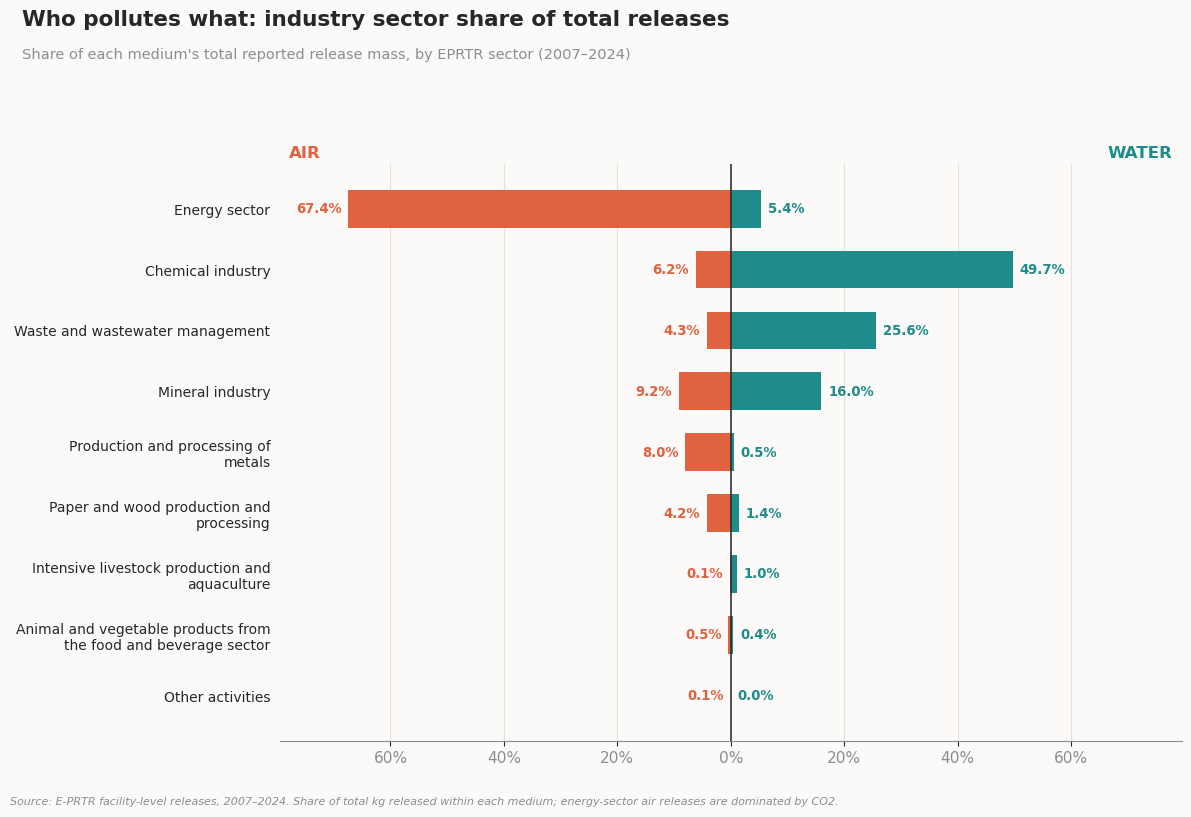

In [58]:
air_sec = air.groupby('eprtr_sectorname')['releases'].sum()
water_sec = water.groupby('eprtr_sectorname')['releases'].sum()

sectors = sorted(set(air_sec.index) | set(water_sec.index))
df = pd.DataFrame({'air': air_sec, 'water': water_sec}).reindex(sectors).fillna(0)
df['air_share'] = df['air'] / df['air'].sum() * 100
df['water_share'] = df['water'] / df['water'].sum() * 100
df['combined'] = (df['air_share'] + df['water_share']) / 2
df = df.sort_values('combined', ascending=True)

labels = [wrap(s, 34) for s in df.index]
y = np.arange(len(df))

fig, ax = plt.subplots(figsize=(12, 7.5))
bar_h = 0.62
ax.barh(y, -df['air_share'], height=bar_h, color=AIR, zorder=3, label='Air')
ax.barh(y, df['water_share'], height=bar_h, color=WATER, zorder=3, label='Water')
ax.axvline(0, color=INK, linewidth=1.1, zorder=4)

for i, (idx, row) in enumerate(df.iterrows()):
    ax.text(-row['air_share'] - 1.2, i, f"{row['air_share']:.1f}%", ha='right', va='center',
             fontsize=9.5, color=AIR, fontweight='bold')
    ax.text(row['water_share'] + 1.2, i, f"{row['water_share']:.1f}%", ha='left', va='center',
             fontsize=9.5, color=WATER, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

max_extent = max(df['air_share'].max(), df['water_share'].max()) + 12
ax.set_xlim(-max_extent, max_extent)
xticks = np.array([-60, -40, -20, 0, 20, 40, 60])
xticks = xticks[np.abs(xticks) <= max_extent]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(t)}%" for t in xticks], color=SUBTLE)

clean_spines(ax, left=False)
ax.tick_params(left=False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)

ax.text(-max_extent*0.98, len(df)-0.15, "AIR", fontsize=12, fontweight='bold', color=AIR, ha='left')
ax.text(max_extent*0.98, len(df)-0.15, "WATER", fontsize=12, fontweight='bold', color=WATER, ha='right')

fig.suptitle("Who pollutes what: industry sector share of total releases",
              fontsize=15.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.04)
fig.text(0.02, 0.975, "Share of each medium's total reported release mass, by EPRTR sector (2007\u20132024)",
          fontsize=10.5, color=SUBTLE)
add_source_note(fig, "Source: E-PRTR facility-level releases, 2007\u20132024. Share of total kg released within each medium; "
                       "energy-sector air releases are dominated by CO2.", y=-0.01)

plt.tight_layout(rect=[0, 0.01, 1, 0.93])
plt.show()

## 2. What are the most released pollutants?

Not a single pollutant appears in both top-10 lists. Air releases are dominated by greenhouse gases and combustion by-products (CO2, CO, SOx, NOx, CH4); water releases are dominated by conventional water-quality parameters (chlorides, organic carbon, nitrogen, phosphorus). Note the log scale on both panels — it's the only way to fit CO2 and trace substances on the same axis.

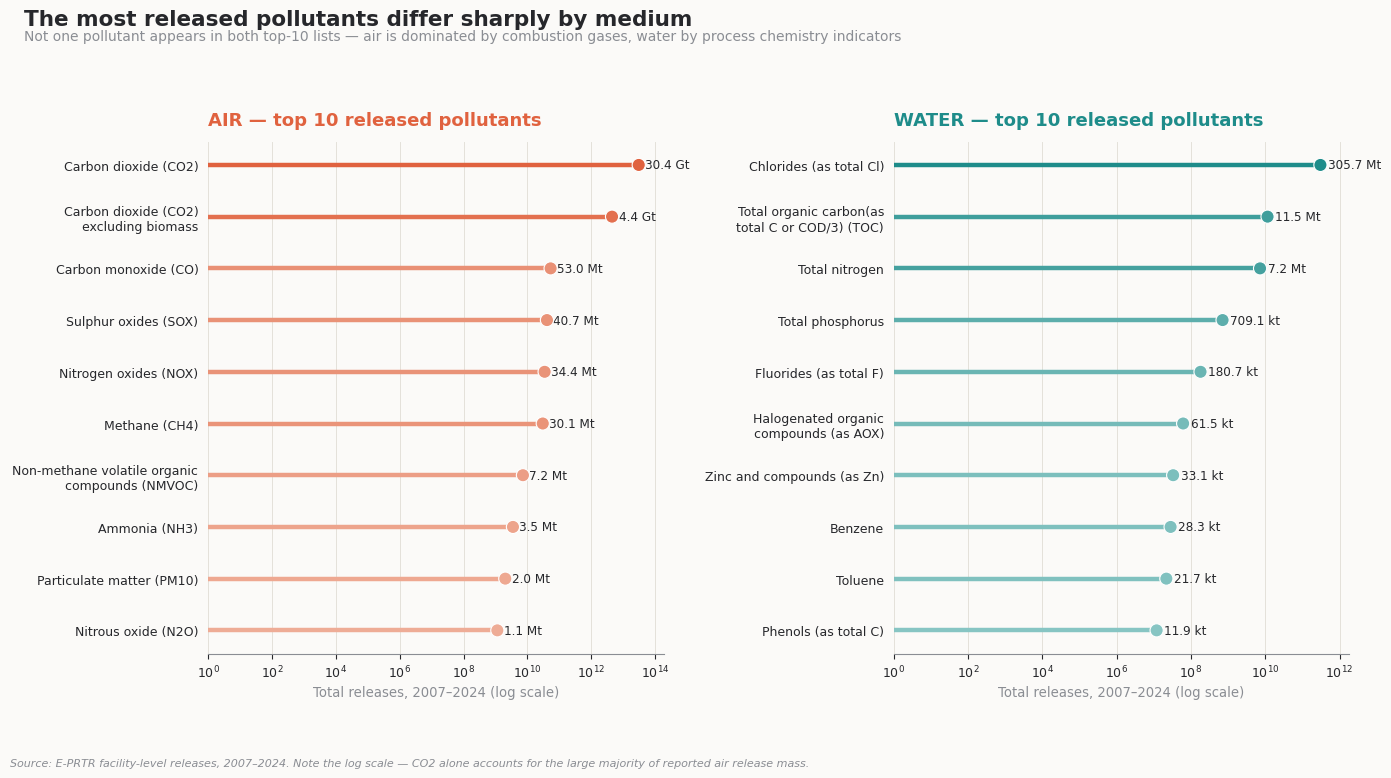

In [59]:
air_top = air.groupby('pollutant')['releases'].sum().sort_values(ascending=False).head(10)
water_top = water.groupby('pollutant')['releases'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, data, color, cmap, title in [
    (axes[0], air_top, AIR, AIR_CMAP, "AIR \u2014 top 10 released pollutants"),
    (axes[1], water_top, WATER, WATER_CMAP, "WATER \u2014 top 10 released pollutants"),
]:
    data = data.sort_values(ascending=True)
    y = np.arange(len(data))
    norm_vals = np.log10(data.values)
    norm = (norm_vals - norm_vals.min()) / (norm_vals.max() - norm_vals.min() + 1e-9)
    colors = [cmap(0.35 + 0.65*n) for n in norm]

    ax.hlines(y, xmin=1, xmax=data.values, color=colors, linewidth=3.2, zorder=3)
    ax.scatter(data.values, y, color=colors, s=90, zorder=4, edgecolor='white', linewidth=0.8)

    ax.set_yticks(y)
    ax.set_yticklabels([wrap(p, 28) for p in data.index], fontsize=9.5)
    ax.set_xscale('log')
    ax.set_xlim(1, data.values.max() * 6)

    for i, v in enumerate(data.values):
        ax.text(v * 1.6, i, fmt_mass(v), va='center', ha='left', fontsize=8.7, color=INK)

    clean_spines(ax, left=False)
    ax.tick_params(left=False, labelsize=9)
    ax.set_xlabel("Total releases, 2007\u20132024 (log scale)", fontsize=9.5, color=SUBTLE)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color, loc='left', pad=12)
    ax.xaxis.grid(True, which='major', color=GRID, linewidth=0.7, zorder=0)

fig.suptitle("The most released pollutants differ sharply by medium",
              fontsize=15.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.03)
fig.text(0.02, 0.985, "Not one pollutant appears in both top-10 lists \u2014 air is dominated by combustion gases, water by process chemistry indicators",
          fontsize=10, color=SUBTLE)
add_source_note(fig, "Source: E-PRTR facility-level releases, 2007\u20132024. Note the log scale \u2014 CO2 alone accounts for the large majority "
                       "of reported air release mass.", y=-0.04)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

## 3. Which regions carry the heaviest burden?

German industrial regions (Düsseldorf, Köln, Brandenburg) top the air ranking, alongside the Czech Severozápad coal basin and Polish industrial regions. For water, Toscana (Italy) and several German regions lead. Note: the map below excludes the UK (no NUTS coverage since Brexit) and Norway — roughly 12% of air records and 27% of water records fall outside the NUTS join, so treat this as indicative of continental patterns rather than a complete European ranking.

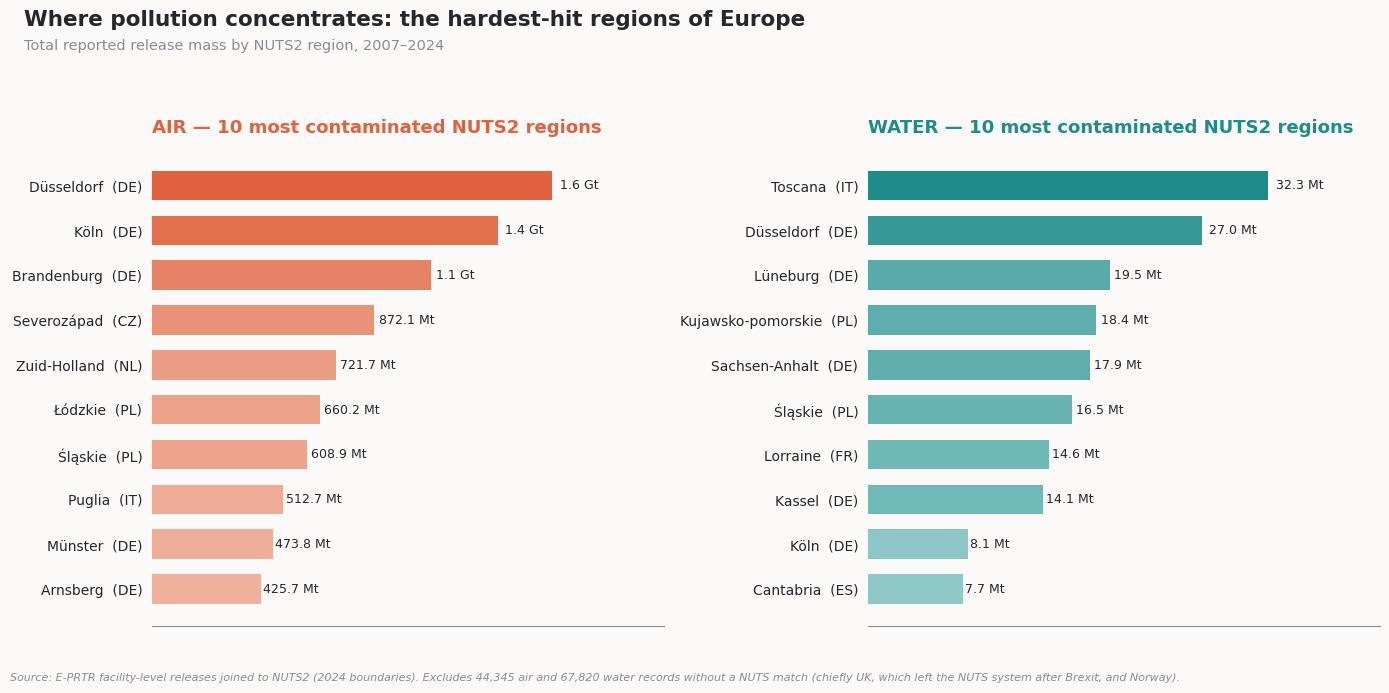

In [60]:
air_n = air.dropna(subset=['nuts_id'])
water_n = water.dropna(subset=['nuts_id'])

air_reg = air_n.groupby(['nuts_name', 'cntr_code'])['releases'].sum().sort_values(ascending=False).head(10)
water_reg = water_n.groupby(['nuts_name', 'cntr_code'])['releases'].sum().sort_values(ascending=False).head(10)

n_excl_air = air['nuts_id'].isna().sum()
n_excl_water = water['nuts_id'].isna().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))

for ax, data, color, cmap, title in [
    (axes[0], air_reg, AIR, AIR_CMAP, "AIR \u2014 10 most contaminated NUTS2 regions"),
    (axes[1], water_reg, WATER, WATER_CMAP, "WATER \u2014 10 most contaminated NUTS2 regions"),
]:
    data = data.sort_values(ascending=True)
    labels = [f"{name}  ({cc})" for (name, cc) in data.index]
    y = np.arange(len(data))
    norm = (data.values - data.values.min()) / (data.values.max() - data.values.min() + 1e-9)
    colors = [cmap(0.3 + 0.7*n) for n in norm]

    ax.barh(y, data.values, color=colors, height=0.66, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)

    for i, v in enumerate(data.values):
        ax.text(v * 1.02, i, fmt_mass(v), va='center', ha='left', fontsize=9, color=INK)

    ax.set_xlim(0, data.values.max() * 1.28)
    clean_spines(ax, left=False)
    ax.tick_params(left=False)
    ax.xaxis.set_visible(False)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color, loc='left', pad=12)

fig.suptitle("Where pollution concentrates: the hardest-hit regions of Europe",
              fontsize=15.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.04)
fig.text(0.02, 0.975, "Total reported release mass by NUTS2 region, 2007\u20132024", fontsize=10.5, color=SUBTLE)

add_source_note(
    fig,
    f"Source: E-PRTR facility-level releases joined to NUTS2 (2024 boundaries). Excludes {n_excl_air:,} air and {n_excl_water:,} water records "
    "without a NUTS match (chiefly UK, which left the NUTS system after Brexit, and Norway).",
    y=-0.03
)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

## 4. Bonus — where are the facilities?

With no shapefile or basemap needed, ~33,000 facility locations are dense enough on their own to trace the outline of Europe. It's also a nice sanity check on the geocoding — the coastlines, the gap over the Alps, and the low-density stretches of Scandinavia and the Baltics all show up exactly where you'd expect.

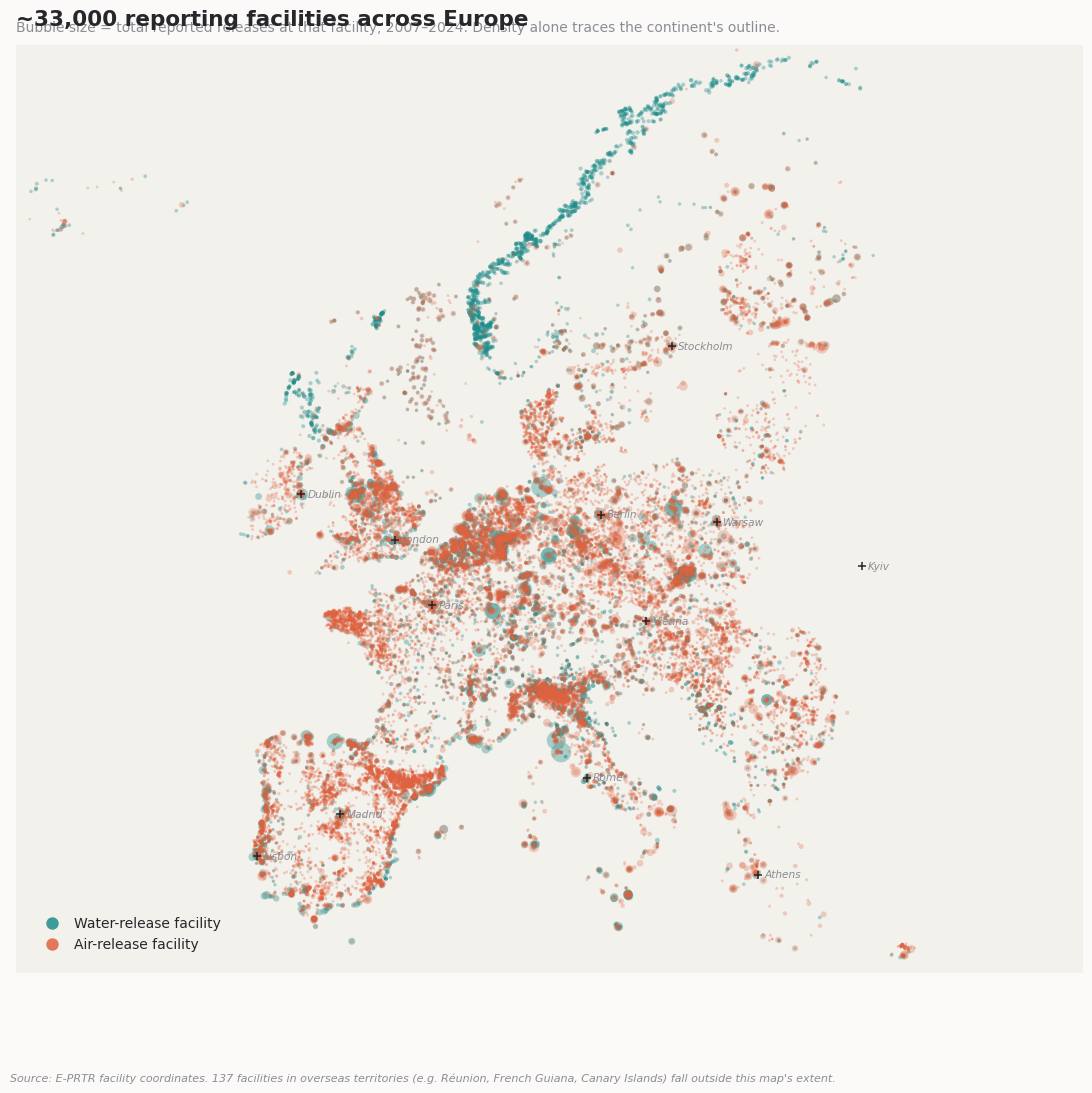

In [61]:
air_fac = air.groupby(['facilityname', 'latitude', 'longitude'], as_index=False)['releases'].sum()
water_fac = water.groupby(['facilityname', 'latitude', 'longitude'], as_index=False)['releases'].sum()

# Europe bounding box (continental + Scandinavia + Mediterranean); excludes overseas territories
LON_MIN, LON_MAX = -25, 45
LAT_MIN, LAT_MAX = 34, 71.5

def crop(d):
    return d[(d['longitude'].between(LON_MIN, LON_MAX)) & (d['latitude'].between(LAT_MIN, LAT_MAX))]

air_fac_c = crop(air_fac)
water_fac_c = crop(water_fac)
n_excl = (len(air_fac) - len(air_fac_c)) + (len(water_fac) - len(water_fac_c))

fig, ax = plt.subplots(figsize=(11, 11.5))

def size_scale(vals, lo=8, hi=260):
    r = np.sqrt(vals / vals.max())
    return lo + r * (hi - lo)

ax.scatter(water_fac_c['longitude'], water_fac_c['latitude'],
           s=size_scale(water_fac_c['releases'], 6, 220),
           color=WATER, alpha=0.35, linewidth=0, zorder=3, label='Water-release facility')
ax.scatter(air_fac_c['longitude'], air_fac_c['latitude'],
           s=size_scale(air_fac_c['releases'], 4, 130),
           color=AIR, alpha=0.28, linewidth=0, zorder=4, label='Air-release facility')

cities = {
    "London": (51.507, -0.128), "Paris": (48.857, 2.352), "Madrid": (40.417, -3.703),
    "Berlin": (52.520, 13.405), "Rome": (41.903, 12.496), "Warsaw": (52.230, 21.012),
    "Stockholm": (59.329, 18.069), "Athens": (37.984, 23.728), "Vienna": (48.208, 16.373),
    "Kyiv": (50.450, 30.524), "Lisbon": (38.722, -9.139), "Dublin": (53.350, -6.260),
}
for name, (clat, clon) in cities.items():
    ax.plot(clon, clat, marker='+', color=INK, markersize=6, mew=1.1, zorder=6)
    ax.text(clon + 0.4, clat, name, fontsize=7.6, color=SUBTLE, va='center', zorder=6, style='italic')

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect(1 / np.cos(np.radians(52)))
ax.set_facecolor("#F3F1EC")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(loc='lower left', frameon=False, fontsize=10, markerscale=1.6,
                     handletextpad=0.6, borderaxespad=1.2)
for lh in legend.legend_handles:
    lh.set_alpha(0.85); lh.set_sizes([80])

ax.set_title("~33,000 reporting facilities across Europe",
              fontsize=15.5, fontweight='bold', color=INK, pad=14, loc='left')
ax.text(0, 1.015, "Bubble size = total reported releases at that facility, 2007\u20132024. Density alone traces the continent's outline.",
         transform=ax.transAxes, fontsize=10, color=SUBTLE)

add_source_note(fig, f"Source: E-PRTR facility coordinates. {n_excl} facilities in overseas territories (e.g. R\u00e9union, French Guiana, "
                       "Canary Islands) fall outside this map's extent.", y=0.01)

plt.tight_layout()
plt.show()

## 5. Bonus — how do countries compare?

Germany, Poland and Italy are the top three polluters overall, but the balance between air and water differs by country. The UK and Netherlands lean more toward air; Italy, Poland and Ireland lean more toward water. Czechia is the most air-skewed of the group — 5.3% of all air releases but only 0.3% of water releases.

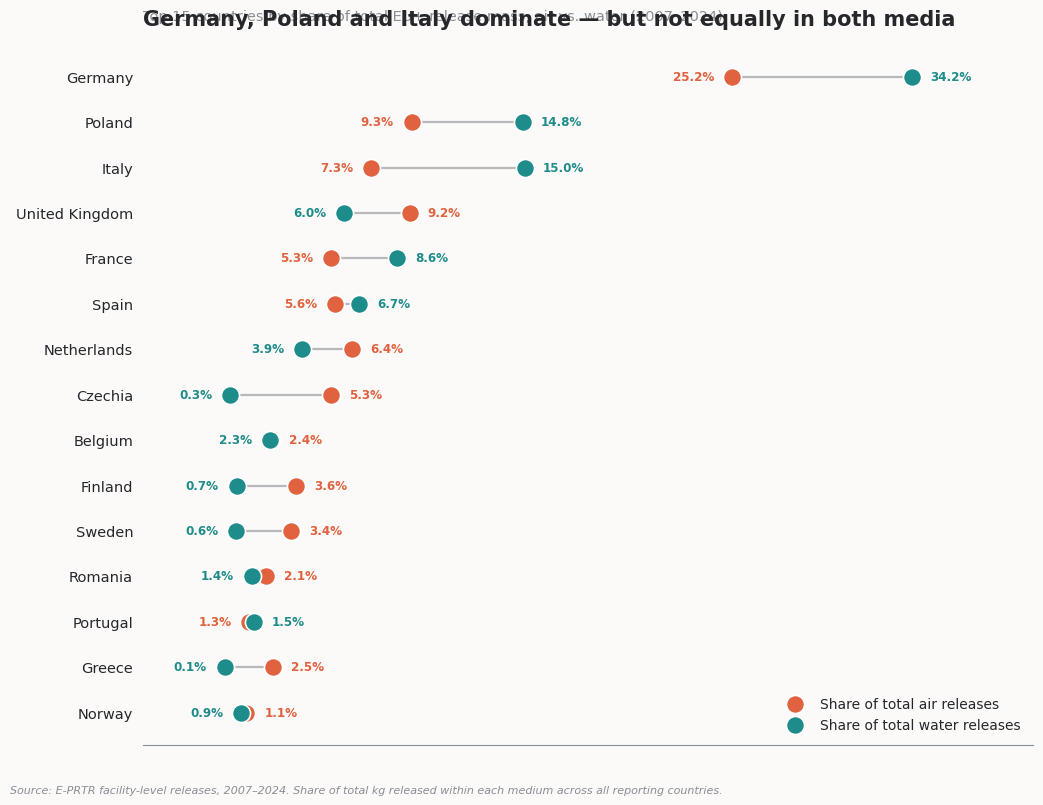

In [62]:
air_c = air.groupby('countryname')['releases'].sum()
water_c = water.groupby('countryname')['releases'].sum()
air_share = air_c / air_c.sum() * 100
water_share = water_c / water_c.sum() * 100
df = pd.DataFrame({'air_share': air_share, 'water_share': water_share}).fillna(0)
df['avg'] = (df['air_share'] + df['water_share']) / 2
df = df.sort_values('avg', ascending=False).head(15)
df = df.sort_values('avg', ascending=True)

y = np.arange(len(df))
fig, ax = plt.subplots(figsize=(10.5, 8))

ax.hlines(y, df['air_share'], df['water_share'], color=SUBTLE, linewidth=1.6, zorder=2, alpha=0.6)
ax.scatter(df['air_share'], y, s=170, color=AIR, zorder=4, edgecolor='white', linewidth=1.2, label='Share of total air releases')
ax.scatter(df['water_share'], y, s=170, color=WATER, zorder=4, edgecolor='white', linewidth=1.2, label='Share of total water releases')

for i, (name, row) in enumerate(df.iterrows()):
    lo, hi = min(row['air_share'], row['water_share']), max(row['air_share'], row['water_share'])
    ax.text(hi + 0.9, i, f"{hi:.1f}%", va='center', fontsize=8.6,
             color=(AIR if row['air_share'] > row['water_share'] else WATER), fontweight='bold')
    ax.text(lo - 0.9, i, f"{lo:.1f}%", va='center', ha='right', fontsize=8.6,
             color=(WATER if row['air_share'] > row['water_share'] else AIR), fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(df.index, fontsize=10.5)
ax.set_xlim(-4, df[['air_share', 'water_share']].values.max() + 6)
ax.set_xticks([])
clean_spines(ax, left=False)
ax.tick_params(left=False)
ax.legend(loc='lower right', frameon=False, fontsize=10)

ax.set_title("Germany, Poland and Italy dominate \u2014 but not equally in both media",
              fontsize=15, fontweight='bold', color=INK, loc='left', pad=14)
ax.text(0, 1.035, "Top 15 countries by share of total EU+ release mass, air vs. water (2007\u20132024)",
         transform=ax.transAxes, fontsize=10.5, color=SUBTLE)
add_source_note(fig, "Source: E-PRTR facility-level releases, 2007\u20132024. Share of total kg released within each medium across all "
                       "reporting countries.", y=-0.02)

plt.tight_layout(rect=[0, 0.01, 1, 0.97])
plt.show()

## 6. Bonus — mass vs. hazard

This is arguably the most important chart in the notebook. Using the health-relevant substance lists already curated earlier in this notebook (`respiratory_chemicals`, `water_disease_chemicals`), only **0.25% of reported air release mass** and **0.03% of reported water release mass** comes from substances with direct, well-established health or toxicity concerns. The rest is bulk-volume material (CO2, chlorides) that's environmentally significant — especially for climate — but isn't "contamination" in the toxicological sense. Ranking by raw mass and ranking by hazard tell very different stories, and it's worth being explicit in any write-up about which one you mean.

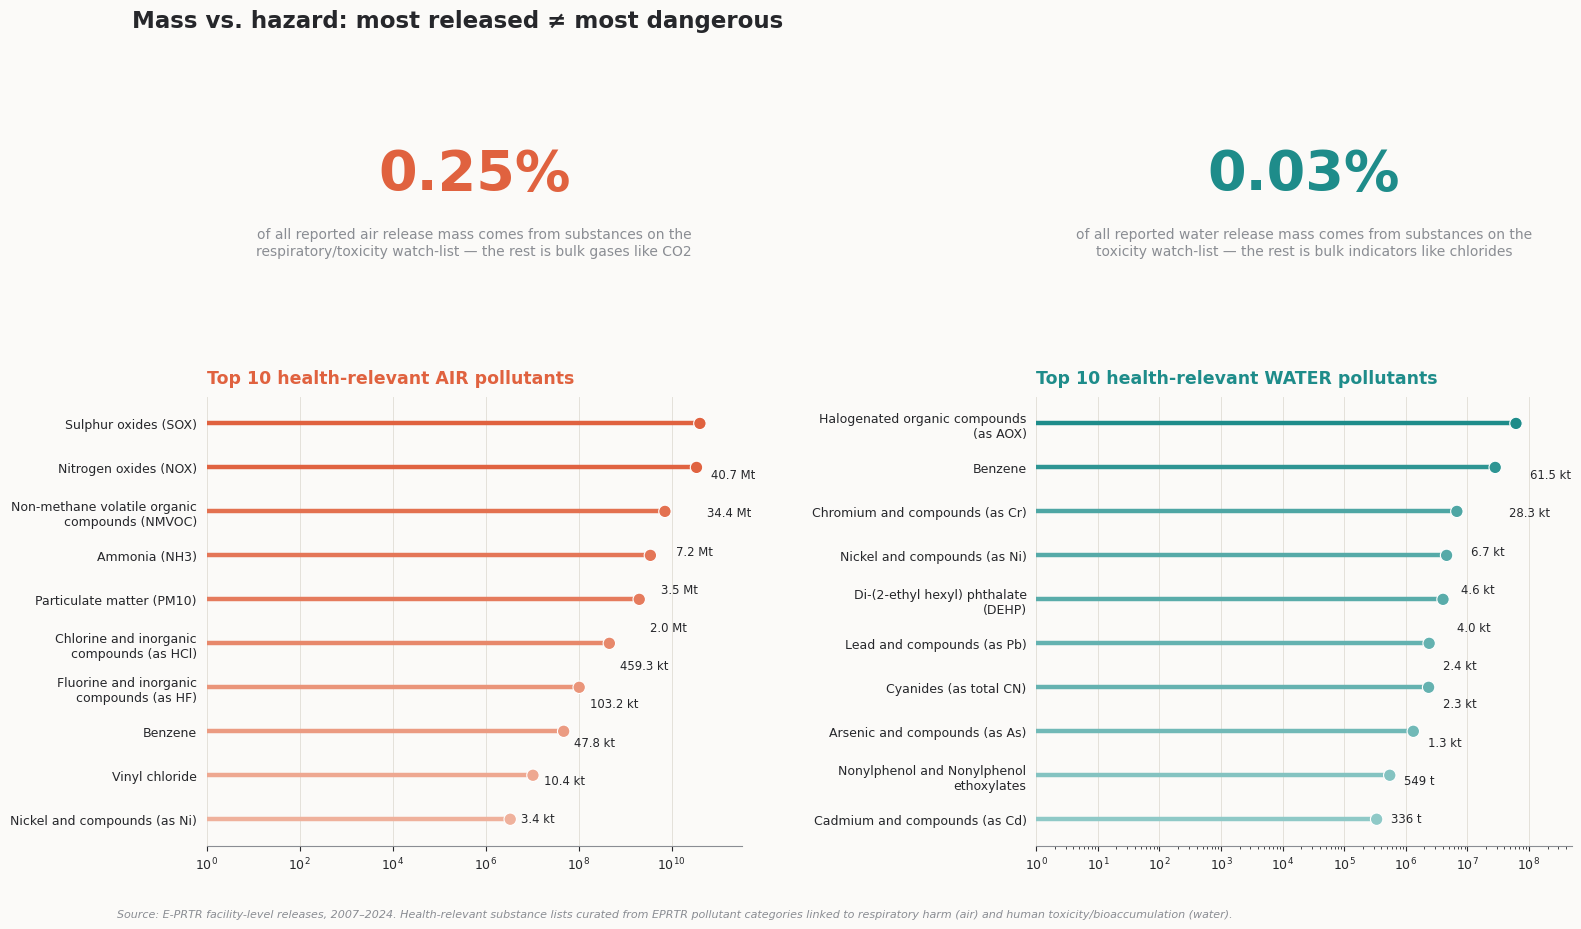

In [63]:
air_total = air['releases'].sum()
water_total = water['releases'].sum()
air_hazard_tot = air[air['pollutant'].isin(respiratory_chemicals)]['releases'].sum()
water_hazard_tot = water[water['pollutant'].isin(water_disease_chemicals)]['releases'].sum()
air_pct = air_hazard_tot / air_total * 100
water_pct = water_hazard_tot / water_total * 100

air_hz = air[air['pollutant'].isin(respiratory_chemicals)].groupby('pollutant')['releases'].sum().sort_values(ascending=False).head(10)
water_hz = water[water['pollutant'].isin(water_disease_chemicals)].groupby('pollutant')['releases'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[0.62, 2.2], hspace=0.5, wspace=0.55,
                        left=0.07, right=0.98, top=0.88, bottom=0.08)

ax_stat1 = fig.add_subplot(gs[0, 0])
ax_stat2 = fig.add_subplot(gs[0, 1])
for ax, pct, color, med in [(ax_stat1, air_pct, AIR, "air"), (ax_stat2, water_pct, WATER, "water")]:
    ax.axis('off')
    ax.text(0.5, 0.62, f"{pct:.2f}%", fontsize=40, fontweight='bold', color=color, ha='center', va='center')
    ax.text(0.5, 0.08,
             f"of all reported {med} release mass comes from substances on the\nrespiratory/toxicity watch-list \u2014 the rest is bulk gases like CO2"
             if med == "air" else
             f"of all reported {med} release mass comes from substances on the\ntoxicity watch-list \u2014 the rest is bulk indicators like chlorides",
             fontsize=10, color=SUBTLE, ha='center', va='center')

for gpos, data, color, cmap, title in [
    (gs[1, 0], air_hz, AIR, AIR_CMAP, "Top 10 health-relevant AIR pollutants"),
    (gs[1, 1], water_hz, WATER, WATER_CMAP, "Top 10 health-relevant WATER pollutants"),
]:
    ax = fig.add_subplot(gpos)
    data = data.sort_values(ascending=True)
    y = np.arange(len(data)) * 1.15
    norm_vals = np.log10(data.values)
    norm = (norm_vals - norm_vals.min()) / (norm_vals.max() - norm_vals.min() + 1e-9)
    colors = [cmap(0.3 + 0.7*n) for n in norm]
    ax.hlines(y, xmin=1, xmax=data.values, color=colors, linewidth=3.2, zorder=3)
    ax.scatter(data.values, y, color=colors, s=80, zorder=4, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([wrap(p, 30) for p in data.index], fontsize=9.3)
    ax.set_xscale('log')
    ax.set_xlim(1, data.values.max() * 8)
    for i, v in enumerate(data.values):
        ax.text(v * 1.7, i, fmt_mass(v), va='center', fontsize=8.4, color=INK)
    clean_spines(ax, left=False)
    ax.tick_params(left=False, labelsize=9)
    ax.set_ylim(-0.7, y.max() + 0.7)
    ax.set_title(title, fontsize=12.5, fontweight='bold', color=color, loc='left', pad=10)
    ax.xaxis.grid(True, which='major', color=GRID, linewidth=0.7, zorder=0)

fig.suptitle("Mass vs. hazard: most released \u2260 most dangerous",
              fontsize=16.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.01)
add_source_note(fig, "Source: E-PRTR facility-level releases, 2007\u20132024. Health-relevant substance lists curated from EPRTR pollutant "
                       "categories linked to respiratory harm (air) and human toxicity/bioaccumulation (water).", y=0.01)
plt.show()

## 7. Bonus — the trend over time

Reported release mass has fallen for both media since 2007, but so has the number of reporting facilities — particularly from 2019 onward. Some of the apparent improvement is likely a genuine effect of decarbonisation and cleaner processes, but part of it may simply be fewer facilities meeting E-PRTR's reporting thresholds, or the most recent 1–2 years still being provisional. Worth flagging as a caveat rather than reading the decline at face value.

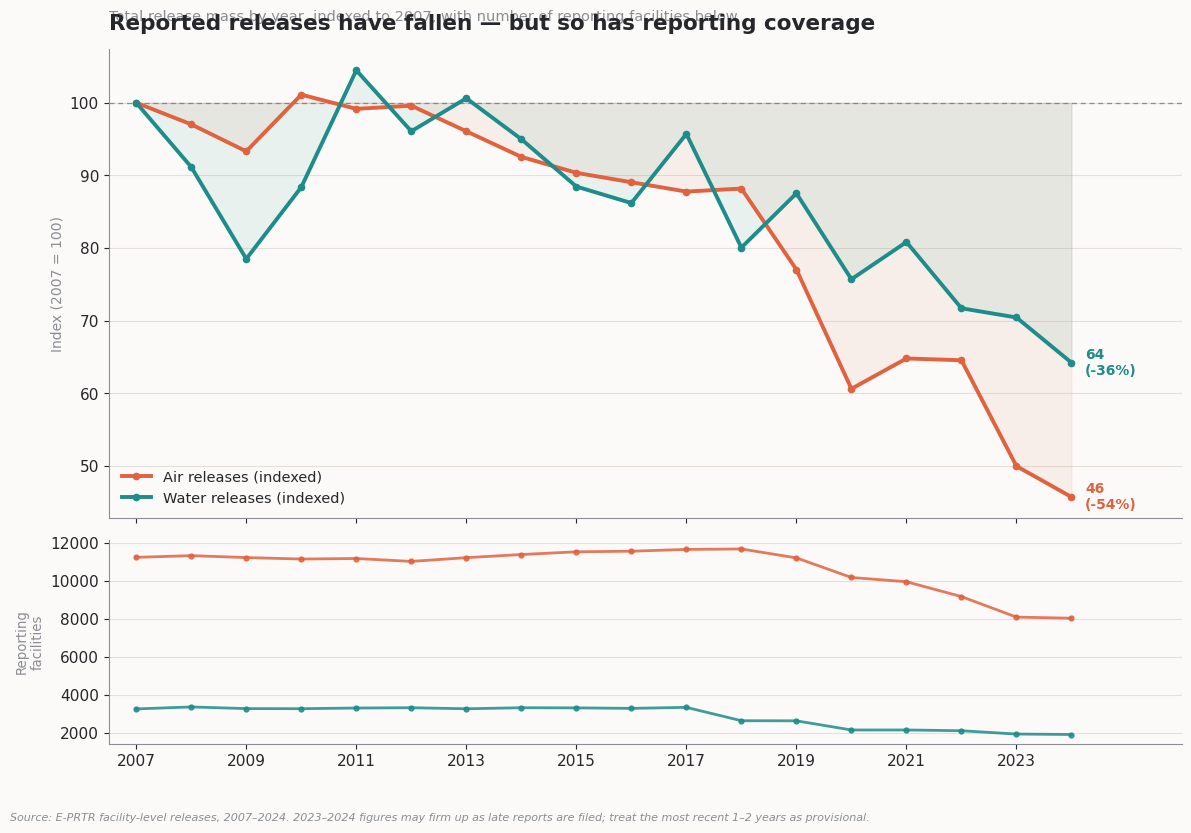

In [64]:
air_yr = air.groupby('reportingyear').agg(releases=('releases', 'sum'), n_facilities=('facilityname', 'nunique'))
water_yr = water.groupby('reportingyear').agg(releases=('releases', 'sum'), n_facilities=('facilityname', 'nunique'))

base_year = 2007
air_idx = air_yr['releases'] / air_yr['releases'].loc[base_year] * 100
water_idx = water_yr['releases'] / water_yr['releases'].loc[base_year] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                  gridspec_kw={'height_ratios': [2.3, 1]})

ax1.plot(air_idx.index, air_idx.values, color=AIR, linewidth=2.8, marker='o', markersize=4.5, label='Air releases (indexed)')
ax1.plot(water_idx.index, water_idx.values, color=WATER, linewidth=2.8, marker='o', markersize=4.5, label='Water releases (indexed)')
ax1.axhline(100, color=SUBTLE, linewidth=0.9, linestyle=(0, (4, 3)), zorder=1)
ax1.fill_between(air_idx.index, air_idx.values, 100, color=AIR, alpha=0.08)
ax1.fill_between(water_idx.index, water_idx.values, 100, color=WATER, alpha=0.08)

end_air, end_water = air_idx.iloc[-1], water_idx.iloc[-1]
ax1.text(air_idx.index[-1] + 0.25, end_air, f"{end_air:.0f}\n({end_air-100:+.0f}%)", color=AIR, fontsize=10, fontweight='bold', va='center')
ax1.text(water_idx.index[-1] + 0.25, end_water, f"{end_water:.0f}\n({end_water-100:+.0f}%)", color=WATER, fontsize=10, fontweight='bold', va='center')

ax1.set_ylabel(f"Index ({base_year} = 100)", fontsize=10, color=SUBTLE)
ax1.legend(loc='lower left', frameon=False, fontsize=10.5)
clean_spines(ax1)
ax1.yaxis.grid(True, color=GRID, linewidth=0.8)
ax1.set_title("Reported releases have fallen \u2014 but so has reporting coverage",
               fontsize=15.5, fontweight='bold', color=INK, loc='left', pad=14)
ax1.text(0, 1.06, f"Total release mass by year, indexed to {base_year}, with number of reporting facilities below",
          transform=ax1.transAxes, fontsize=10.5, color=SUBTLE)

ax2.plot(air_yr.index, air_yr['n_facilities'].values, color=AIR, linewidth=2, marker='o', markersize=3.5, alpha=0.85)
ax2.plot(water_yr.index, water_yr['n_facilities'].values, color=WATER, linewidth=2, marker='o', markersize=3.5, alpha=0.85)
ax2.set_ylabel("Reporting\nfacilities", fontsize=9.5, color=SUBTLE)
clean_spines(ax2)
ax2.yaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_xticks(list(range(2007, 2025, 2)))
ax2.set_xlim(2006.5, 2026)
ax1.set_xlim(2006.5, 2026)

add_source_note(fig, "Source: E-PRTR facility-level releases, 2007\u20132024. 2023\u20132024 figures may firm up as late reports are filed; "
                       "treat the most recent 1\u20132 years as provisional.", y=-0.02)

plt.tight_layout(rect=[0, 0.015, 1, 1])
plt.show()

## 8. Health evolution throughout the years


In [65]:
df_mortality = df_mortality_nuts2_long

icd10_names = {
    'A_B': 'Infectious and parasitic diseases',
    'B15-B19_B942': 'Viral hepatitis',
    'C33_C34': 'Trachea/bronchus/lung cancer',
    'I': 'Circulatory diseases (total)',
    'I20-I25': 'Ischaemic heart disease',
    'I20_I23-I25': 'Ischaemic heart disease (subset)',
    'I21_I22': 'Acute myocardial infarction',
    'I60-I69': 'Cerebrovascular diseases',
    'J': 'Respiratory diseases (total)',
    'J40-J44_J47': 'Chronic lower respiratory diseases',
    'J40-J47': 'Chronic lower respiratory diseases (all)',
    'J45_J46': 'Asthma',
    'N00-N29': 'Diseases of the urinary system',
    'TOXICO': 'Drug dependence',
    'X40-X49': 'Accidental poisoning'
}
df_mortality['disease_name'] = df_mortality['icd10'].map(icd10_names)

df_m = df_mortality[(df_mortality['sex'] == 'T') & (df_mortality['age'] == 'TOTAL')]

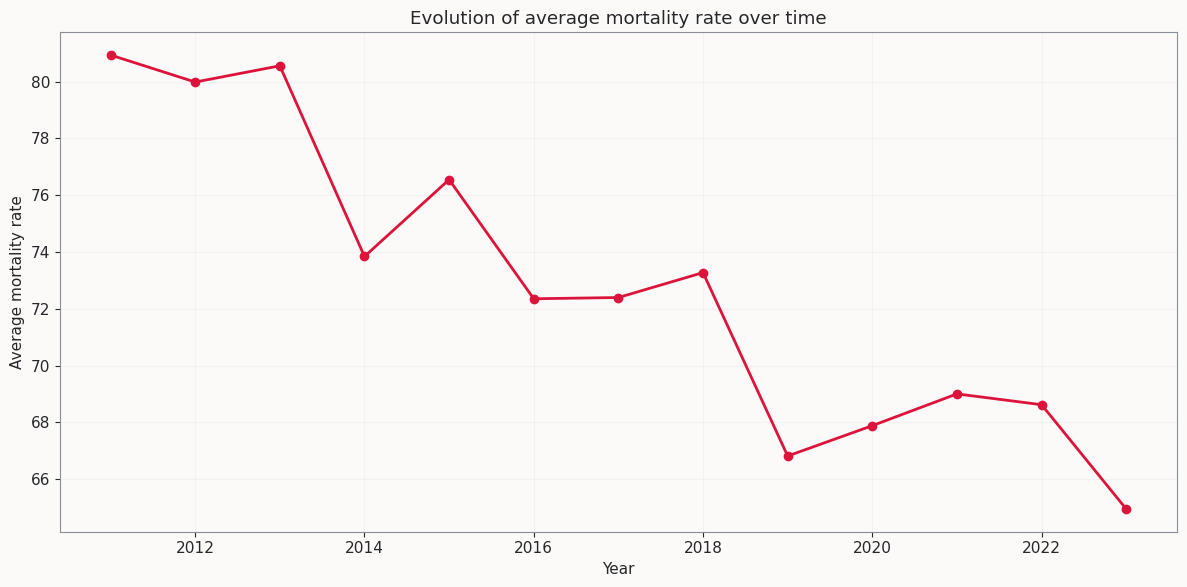

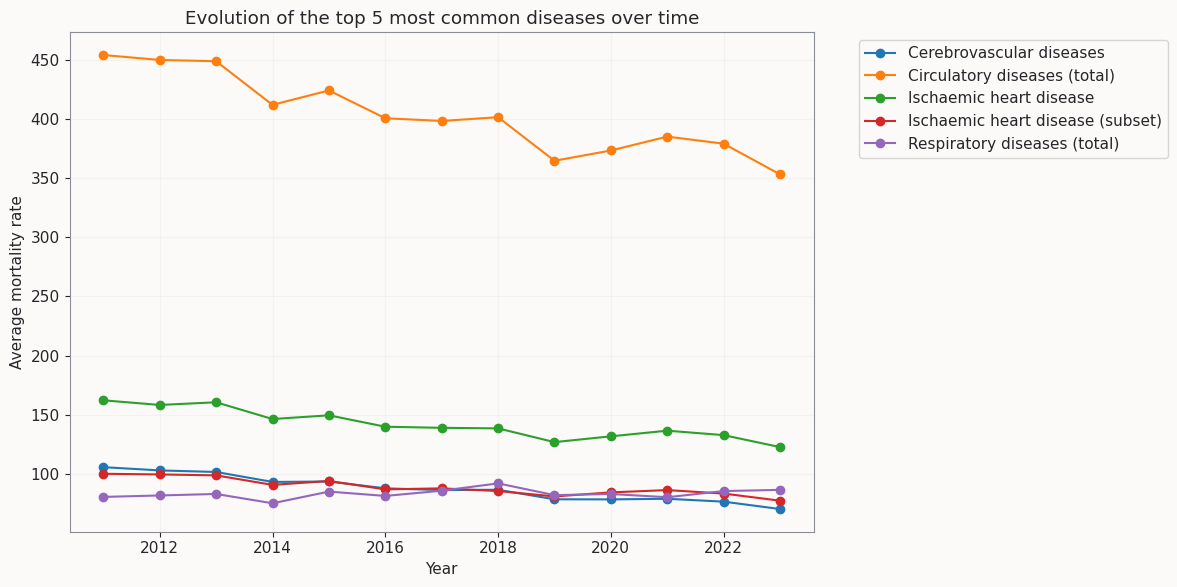

In [66]:
mortality_by_year = df_m.groupby('year')['mortality_rate'].mean()

plt.figure(figsize=(12, 6))
plt.plot(mortality_by_year.index, mortality_by_year.values, marker='o', linewidth=2, color='crimson')
plt.title('Evolution of average mortality rate over time')
plt.xlabel('Year')
plt.ylabel('Average mortality rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evolution of each disease (top 5, see section 3) over time
top5_diseases = df_m.groupby('disease_name')['mortality_rate'].mean().sort_values(ascending=False).head(5).index
df_top5 = df_m[df_m['disease_name'].isin(top5_diseases)]
pivot_top5 = df_top5.groupby(['year', 'disease_name'])['mortality_rate'].mean().unstack()

plt.figure(figsize=(12, 6))
for disease in pivot_top5.columns:
    plt.plot(pivot_top5.index, pivot_top5[disease], marker='o', label=disease)
plt.title('Evolution of the top 5 most common diseases over time')
plt.xlabel('Year')
plt.ylabel('Average mortality rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. life expectancy evolution


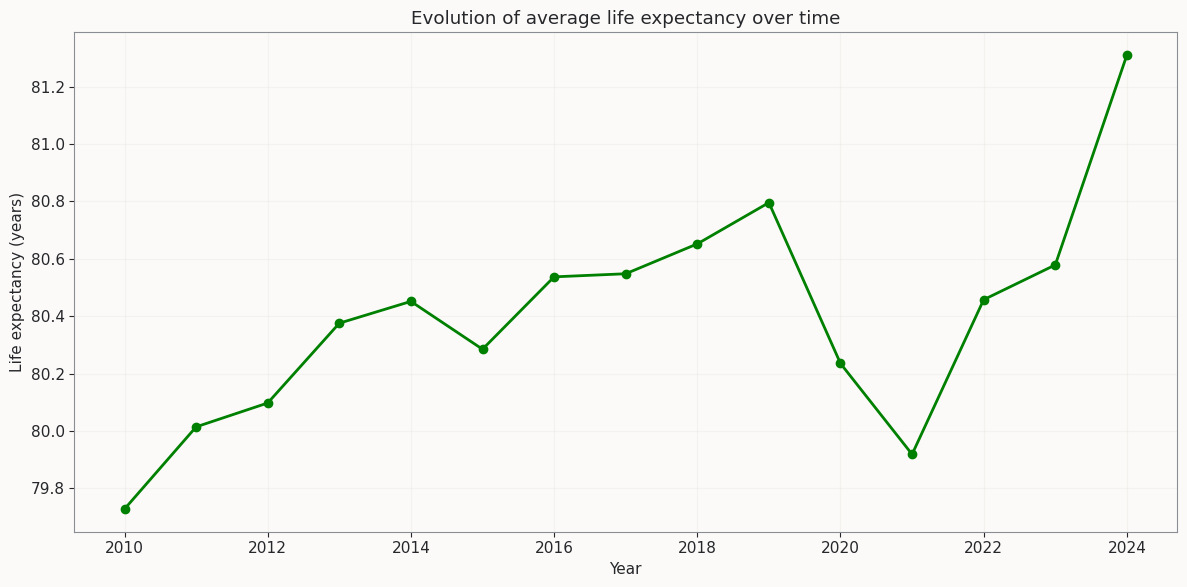

In [67]:
df_life = df_life_exp_nuts2_long_clean
df_life['life_expectancy'] = df_life['life_expectancy'].str.replace(',', '.').astype(float)

life_by_year = df_life[df_life['sex'] == 'T'].groupby('year')['life_expectancy'].mean()

plt.figure(figsize=(12, 6))
plt.plot(life_by_year.index, life_by_year.values, marker='o', color='green', linewidth=2)
plt.title('Evolution of average life expectancy over time')
plt.xlabel('Year')
plt.ylabel('Life expectancy (years)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. TOP 5 most common deseases

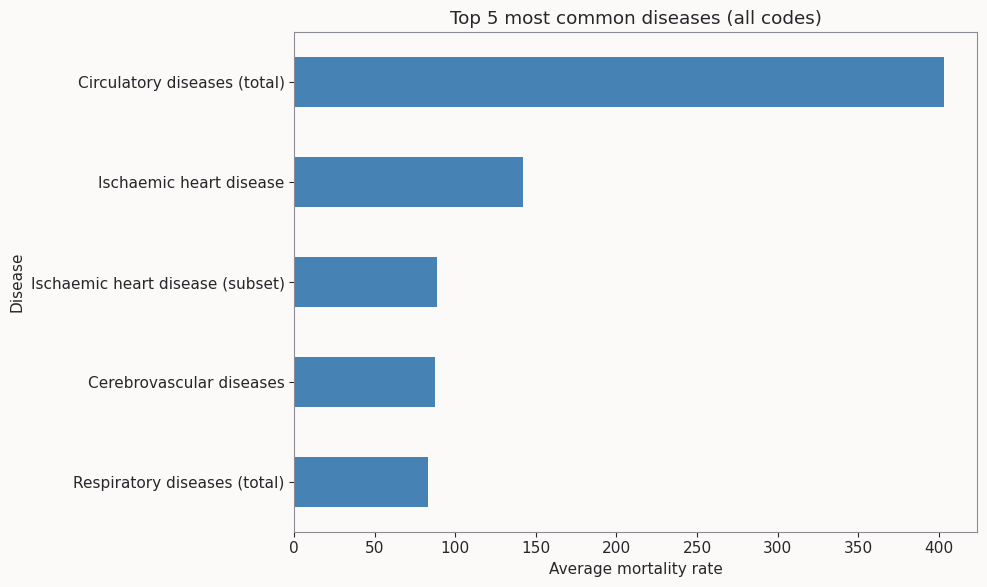

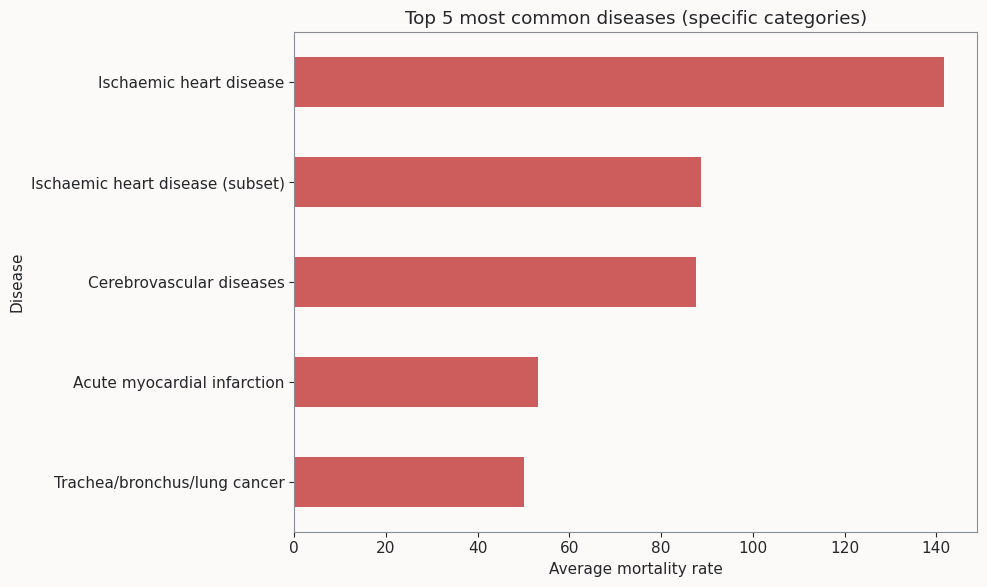

In [68]:
top5_all = df_m.groupby('disease_name')['mortality_rate'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
top5_all.plot(kind='barh', color='steelblue')
plt.title('Top 5 most common diseases (all codes)')
plt.xlabel('Average mortality rate')
plt.ylabel('Disease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

df_m_specific = df_m[~df_m['icd10'].isin(['I', 'J'])]
top5_specific = df_m_specific.groupby('disease_name')['mortality_rate'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
top5_specific.plot(kind='barh', color='indianred')
plt.title('Top 5 most common diseases (specific categories)')
plt.xlabel('Average mortality rate')
plt.ylabel('Disease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Notes & limitations

- **Units:** release figures are treated as kilograms/year (the standard E-PRTR unit). Please confirm against your source documentation.
- **NUTS coverage:** the UK (post-Brexit) and Norway are largely absent from the NUTS-region views (charts 3 and, partially, 4); they're still included in the sector, pollutant, and country-level views.
- **Air/water are not combined into one ranking** for sectors, pollutants, or regions, because air release mass is roughly 100–1000× larger than water release mass (mostly due to CO2). Combining them would just reproduce the air ranking and hide the water signal.
- **2023–2024 data** may still be provisional as late reports are filed — treat the last one to two years of any trend as an early read.
- All charts were generated from `air_nuts_clean.csv` and `water_nuts_clean.csv` — rerun the cells above if you refresh those exports.